In [160]:
!pip install albumentations -q

In [161]:
# importando a biblioteca
import torch
import albumentations as A
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO

In [188]:
# aqui baixa a imagem do link eu pego tudo normalmente do pinterest
url = "https://i.pinimg.com/736x/1b/5e/81/1b5e81f099240080f0e20b317edf2e24.jpg"
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert("RGB")
imagem_np = np.array(img)

In [189]:

# Aqui usa rotação brilho distorção e inversão horizontal
transformador = A.Compose([
    A.HorizontalFlip(p=0.5), # Inverte esquerda/direita
    A.RandomBrightnessContrast(p=0.5), # Muda brilho e contraste
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=45, p=0.5), # Gira e dá zoom
    A.HueSaturationValue(p=0.5), # Muda as cores
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


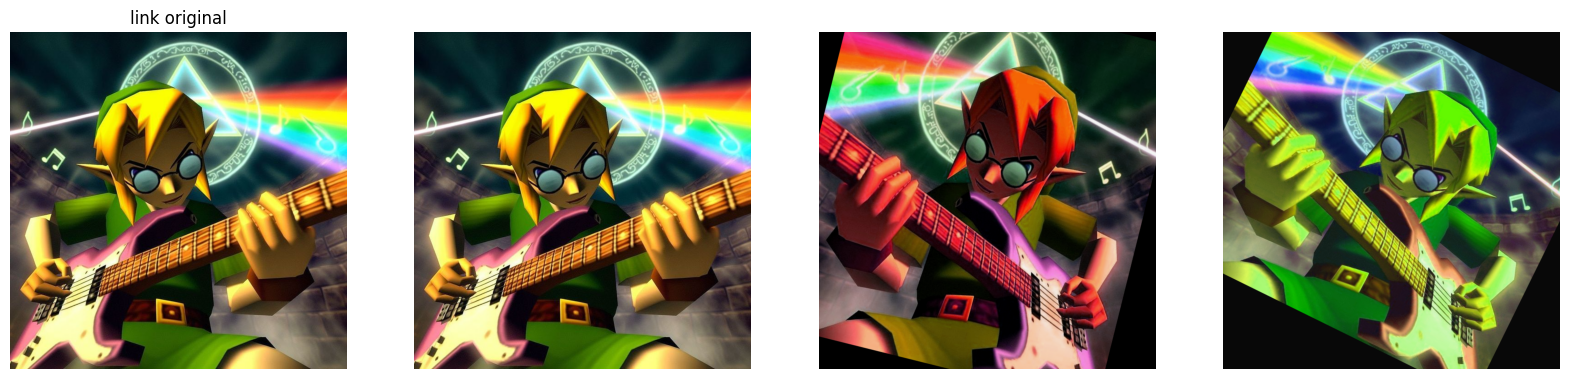

In [195]:
# gerando e exibindo os resultados
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].imshow(imagem_np)
axs[0].set_title("link original")
axs[0].axis('off')

for i in range(1, 4):
    aumentada = transformador(image=imagem_np)["image"]
    axs[i].imshow(aumentada)
    axs[i].axis('off')